# Imports

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Sklearn's
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)


###  How MNIST Data is Stored
While all computer data is technically stored in binary (0s and 1s) at the hardware level, the MNIST dataset represents images as **numerical pixel intensities**, not binary values.
*   **Pixel Intensities:** Each of the 70,000 images in the MNIST set is 28 × 28 pixels, totaling **784 features**.
*   **Values:** Each feature (pixel) is a number from **0 to 255**. In this scale, 0 represents white, 255 represents black, and the numbers in between represent various shades of gray.
*   **Format:** When you fetch the data using Scikit-Learn, it is typically handled as **NumPy arrays** of these 8-bit integers or floats.

### Why "Binary" Appears in the Code
The confusion often comes from the code used to display the images:
*   **`cmap="binary"`:** When using Matplotlib's `imshow()` function to see a digit, the source uses the argument `cmap="binary"`. This is simply a **grayscale color map** choice for the visualization. It tells the computer to map the value 0 to white and 255 to black so that the image is easy for humans to read in a notebook. It does not change the underlying data into 1s and 0s.


In [3]:
X, y = mnist.data, mnist.target

In [4]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [5]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [6]:
X.shape

(70000, 784)

In [7]:
y.shape

(70000,)

**There are 70,000 images, and each image has 784 features.
And Each 784 numbers/features or one row is one image.**

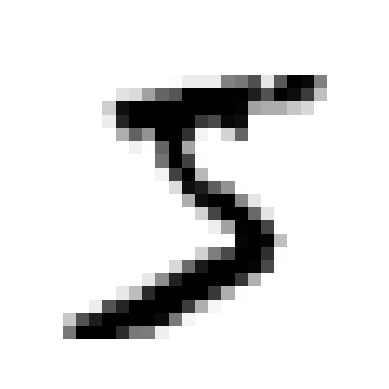

In [8]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    # It takes the flat line of 784 numbers and folds it into a 28x28 square.
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
'''
some_digit is now a 1D array containing exactly 784 numbers. 
Every number represents the darkness of a single 
pixel (from 0 for pure white to 255 for pitch black).
'''
plot_digit(some_digit)
plt.show()

This looks like a 5, and indeed that’s what the label tells us

In [9]:
y[0]

'5'

But wait! You should always create a test set and set it aside before
inspecting the data closely. The MNIST dataset returned by fetch_openml() is actually already split into a training set (the first 60,000
images) and a test set (the last 10,000 images)

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### Wait, why aren't we using `train_test_split()`?
In your previous project, you used `train_test_split()` to randomly shuffle and split the data. 

You might be wondering: *"Why did the book just slice it manually here? What if all the '9's are at the end of the file?"*

This is a special case for the MNIST dataset. The researchers who created MNIST **already did the work for you**. 
*   They intentionally put the first 60,000 mixed images as the "Training" set.
*   They intentionally put the last 10,000 mixed images as the "Test" set. 

Because the dataset is already perfectly shuffled and officially split by the creators, we don't need to use `train_test_split()`. We just trust their official split.


# Training a Binary Classifier

Let’s simplify the problem for now and only try to identify one digit—for
example, the number 5. This “5-detector” will be an example of a binary
classifier, capable of distinguishing between just two classes, 5 and non-5

In [11]:
y_train_5 = (y_train == '5')
'''
"Look at every single label. If it is a '5',
make it True. If it is anything else, make it False."

y_train = ['5', '0', '4', '1', '9', '5']
y_train_5 = [True, False, False, False, False, True]
'''

y_test_5 = (y_test == '5')

Now let’s pick a classifier and train it. A good place to start is with a
stochastic gradient descent (SGD, or stochastic GD) classifier, using Scikit-
Learn’s **SGDClassifier** class. 


**SGDClassifier** is an algorithm that does **Stochastic Gradient Descent** Things this, but in a 784-dimensional space (because there are 784 pixels). It looks at the data, makes a guess at where to draw the line, checks how many mistakes it made, and then shifts the line slightly to make fewer mistakes. It repeats this process thousands of times until it finds the best possible line to separate "5s" from "non-5s".

In [12]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None



### What is `SGDClassifier` and what does it do?
**SGDClassifier** is an algorithm that does **Stochastic Gradient Descent** Things this, but in a 784-dimensional space (because there are 784 pixels). It looks at the data, makes a guess at where to draw the line, checks how many mistakes it made, and then shifts the line slightly to make fewer mistakes. It repeats this process thousands of times until it finds the best possible line to separate "5s" from "non-5s".

### Why does it need `random_state=42`?
Remember how I said SGD "shifts the line slightly" over and over? To do this efficiently, it doesn't look at all 60,000 images at once. It grabs a few images **in a random order**, adjusts the line, grabs the next few, and adjusts again. This "random order" is the **Stochastic** part of SGD.



### The Big Question: Why pass ALL of `X_train`, but only the 5-filtered 

**How they connect (The Pairs):**
Scikit-Learn pairs them up by their row index. It looks at them side-by-side like this:
*   **Row 0:** `X_train[0]` (Image of a 5) + `y_train_5[0]` (Answer: **True**) ➡️ *Model learns: "Okay, THIS is what a 5 looks like."*
*   **Row 1:** `X_train[1]` (Image of a 2) + `y_train_5[1]` (Answer: **False**) ➡️ *Model learns: "Okay, do NOT put THIS inside the 5 boundary."*
*   **Row 2:** `X_train[2]` (Image of a 5) + `y_train_5[2]` (Answer: **True**) ➡️ *Model learns: "Okay, THIS is also a 5."*



In [13]:
sgd_clf.predict([some_digit])

array([ True])

The classifier guesses that this image represents a 5 (True). Looks like it
guessed right in this particular case! Now, let’s evaluate this model’s
performance

# Performance Measures

**Evaluating a classifier is often significantly trickier than evaluating a
regressor, so we will spend a large part of this chapter on this topic.**

### Measuring Accuracy Using Cross-Validation

In [14]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

Wow! Above 95% accuracy (ratio of correct predictions) on all cross-
validation folds?

In [15]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# You pass the images (X_train) and the answers (y_train_5).
print(any(dummy_clf.predict(X_train)))

False


In [16]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])


### 1. The Trap: Why 95% is a Lie (The "Accuracy Trap")
Think about the MNIST dataset. There are 10 digits (0 through 9). That means only about **10%** of the images are the number 5. The other **90%** are "non-5s".

Imagine a lazy student takes a test where 90% of the questions are "Is this a 5?" and 10% are "Is this a 2?". 
Instead of studying, the student just writes **"NO"** on every single answer sheet. 

* Did they get the 10% of 5s right? No.
* Did they get the 90% of non-5s right? Yes!
* **Final Score:** 90% Accuracy.

This happens all the time in the real world with **Imbalanced Data**. For example: *"Build a model to detect credit card fraud."* 99.9% of transactions are legal. A model that just guesses "Legal" every time will be 99.9% accurate, but it is completely useless.

---

### 2. What is a Dummy Classifier?
A `DummyClassifier` is Scikit-Learn’s way of building that **lazy student**. 

It doesn't look at the images. It doesn't do any math. It just looks at the answer key (`y_train`), finds the most common answer (in this case, `False` / "Not a 5"), and guesses that exact same answer for every single image.

We use it to establish a **baseline**. If your fancy model can't beat the Dummy Classifier, your fancy model is useless.

---

### 3. The Literal Translation
You ran a 3-fold cross-validation (`cv=3`). This means Scikit-Learn chopped your data into 3 pieces and tested the model 3 separate times. 

The output `array([0.90965, 0.90965, 0.90965])` means:
*   **Fold 1:** The model got **90.96%** of the answers right.
*   **Fold 2:** The model got **90.96%** of the answers right.
*   **Fold 3:** The model got **90.96%** of the answers right.

### 4. The "Lazy Student" Proof
How did this model get 91% without looking at a single pixel? 

Because it’s the `DummyClassifier`. It completely ignored the images (`X_train`). It just looked at the answer key (`y_train_5`), saw that roughly **91% of the images are NOT 5s**, and decided to guess **"False" for every single image.**

*   Did it correctly identify any actual 5s? **No. (0%)**
*   Did it correctly identify the non-5s? **Yes. (100%)**
*   **Overall Accuracy:** ~91%.



**Conclusion**: This demonstrates why accuracy is generally not the preferred performance measure for classifiers, especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others). A much better way to evaluate the performance of a classifier is to look at the confusion matrix (CM)

### Confusion Matrices

In [17]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [18]:
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

- Each row in a confusion matrix represents an actual class, while each column represents a predicted class. 

1. Top-Left (53892): True Negatives. The model correctly identified these images as "Not 5". (This is the easy part!)

2. Top-Right (687): False Positives. The model looked at these images that were not 5s, but it incorrectly yelled "It's a 5!"

3. Bottom-Left (1891): False Negatives. The model looked at these images that were 5s, but it missed them and said "Not a 5".

4. Bottom-Right (3530): True Positives. The model successfully found these actual 5s.

**Out of 5,421 actual 5s in the dataset, your model only found 3,530 of them. It missed 1,891 of them. At the same time, it accidentally accused 687 non-5s of being 5s.**

In [19]:
y_train_perfect_predictions = y_train_5 #predend we reach prefectons
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

**Visualizing the "Main Diagonal"**
The most important takeaway from the perfect confusion matrix is that a **perfect classifier** will have non-zero values **only on its main diagonal** (the line running from the top left to the bottom right). 
*   **Top Left (True Negatives):** All non-5s were correctly identified as non-5s.
*   **Bottom Right (True Positives):** All 5s were correctly identified as 5s.



### Precision and Recall

### 1. Precision: "About the Model's Predictions"
 *"Out of all the times the model yelled 'YES', what percentage of those times was it actually right?"*

### 2. Recall: "About the Actual Data"
*"Out of all the actual 'YES' items hiding in the data, what percentage did the model successfully find?"*

---

### Let's lock it in with the "Club Bouncer" Analogy

*   **Precision (The Bouncer's Accuracy):** Out of the 50 people he let in, 40 were actually celebrities, and 10 were just random fans. 
    *   When the bouncer says "You can come in," he is **80% right** (40/50). That is **Precision**.
*   **Recall (The Data's Coverage):** There were 100 celebrities in the line. The bouncer only let 40 of them in. He accidentally turned away 60 celebrities! 
    *   He only caught **40% of the actual celebrities** (40/100). That is **Recall**.


In [20]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

What it means: When your model looks at an image and confidently says, "I am 100% sure this is a 5!", it is actually correct 83.7% of the time.

In [21]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

What it means: Out of all the actual number 5s hiding in the entire dataset, your model only managed to find 65.1% of them.

Now our 5-detector does not look as shiny as it did when we looked at its
accuracy. When it claims an image represents a 5, it is correct only 83.7%
of the time. Moreover, it only detects 65.1% of the 5s


**3. The $F_1$ Score: A Balanced Metric**
To compare two classifiers easily, you can combine precision and recall into a single number called the **$F_1$ score**. It is the **harmonic mean** of the two.
*   Unlike a regular average, the harmonic mean gives much more weight to **low values**. 
* because of that A classifier will only get a high $F_1$ score if **both** recall and precision are high.


In [22]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847


### The Precision/Recall Trade-off**
You cannot maximize both precision and recall simultaneously; increasing one typically reduces the other. This is because classifiers like the `SGDClassifier` calculate a score for each instance and compare it to a **decision threshold**:
*   **Raising the threshold:** Makes the model more "picky." This **increases precision** (fewer false positives) but **decreases recall** (it misses more true positives).
*   **Lowering the threshold:** Makes the model more "lenient." This **increases recall** (it catches more true positives) but **decreases precision** (it lets in more false positives).

### **5. Deciding Which to Prioritize**
The "right" balance depends on your specific project:
*   **High Precision is better for:** Applications like **filters for kids' videos**, where it is better to reject some good videos (low recall) as long as you keep only safe ones (high precision).
*   **High Recall is better for:** Applications like **detecting shoplifters** on surveillance cameras, where it is fine to have many false alarms (low precision) as long as you catch almost every thief (high recall).



*   If you move the threshold to the **Right** (make it stricter), your **Precision goes UP**, but your **Recall goes DOWN**. (You stop making false alarms, but you start missing targets).
*   If you move the threshold to the **Left** (make it lenient), your **Recall goes UP**, but your **Precision goes DOWN**. (You catch all the targets, but you start making a lot of false alarms).

How do you use this in real life?

In Scikit-Learn, you don't just have to accept the default threshold. You can actually ask the model for its raw "decision scores" for every image, and then **you can draw your own line** wherever you want! 

If you are building that YouTube Kids filter we talked about, you would look at this graph and say, *"I don't care about Recall. Move the threshold all the way to the right so my Precision is 100%!"*

Does seeing the "velvet rope" move left and right on the number line make the trade-off make sense?

Scikit-Learn's predict() method has a hardcoded rule for the SGDClassifier: If the score is greater than 0, guess True. If it's less than 0, guess False.

You cannot tell predict() to change that 0 to a 100 or a -50. It refuses.
So, to change the threshold (the velvet rope), we have to bypass predict() entirely. We ask the model for its raw, unfiltered confidence scores, and then we apply our own threshold manually.

In [23]:
y_scores = sgd_clf.decision_function([some_digit])
'''
What it does: Instead of asking the model "Is this a 5?", we ask the model: "How confident are you that this is a 5? Give me the raw math score."
How it works: decision_function() calculates the distance of the image from the model's decision boundary (the line we talked about earlier
'''

y_scores
# this is confidence score


array([2164.22030239])

In [24]:

'''
What it does: This is where you take control. You manually check if the raw score is higher than your chosen threshold.
The Math: Is 2164.22 > 0? Yes.
The Result: array([ True])


"The SGDClassifier uses a threshold equal to 0, 
so the preceding code returns the same result as the predict() method
'''
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [25]:
print(y_some_digit_pred)

[ True]


In [26]:
# Let's increase the threshold
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

Remember, the raw score for that image of a 5 was 2164.22.
When you set the threshold to 3000, you're asking: "Is 2164.22 greater than 3000?"
No, it's not. So the prediction becomes False.
The Reality Check:
The image actually is a 5. But because you raised the threshold too high, the model missed it! This is exactly what a False Negative is.
This proves the trade-off: By raising the threshold to 3000, you made the model more selective (higher precision), but it started missing actual 5s (lower recall).


**How do you decide which threshold to use?**

- To answer these questions, you need to test every possible threshold and see what happens to Precision and Recall at each one.

First, use the cross_val_predict() function to get the scores of all instances in the
training set, but this time specify that you want to return decision scores
instead of predictions:

and With these scores, use the precision_recall_curve() function to
compute precision and recall for all possible thresholds (the function adds a
last precision of 0 and a last recall of 1, corresponding to an infinite
threshold)

In [27]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
'''
method="decision_function": This is the magic parameter. 
Instead of returning True or False predictions, 
it returns the raw confidence scores for every single image.
'''


'\nmethod="decision_function": This is the magic parameter. \nInstead of returning True or False predictions, \nit returns the raw confidence scores for every single image.\n'

In [28]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

**Because there are 60,000 images in your training set!**
The function goes through your dataset image by image:
- Image #0 (a 5): Score = 1200.93 (Positive, so it thinks it's a 5)
- Image #1 (a 2): Score = -26883.79 (Very negative, definitely not a 5)
- Image #2 (an 8): Score = -33072.03 (Very negative, not a 5)
...and so on for all 60,000 images.

In [29]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

What does it return?

It gives you three massive arrays:
- precisions: A list of Precision values (one for each threshold).
- recalls: A list of Recall values (one for each threshold).
- thresholds: A list of the threshold values it tested.

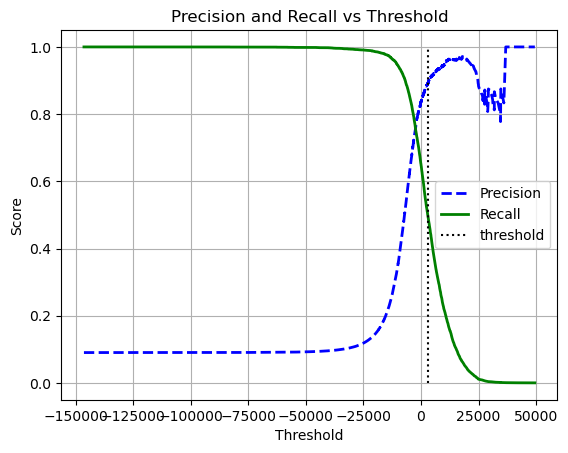

In [30]:
import matplotlib.pyplot as plt

# Plot Precision (Blue dashed line)
plt.plot(thresholds, precisions[:-1], 
         color='blue', 
         linestyle='--', 
         label='Precision', 
         linewidth=2)

# Plot Recall (Green solid line)
plt.plot(thresholds, recalls[:-1], 
         color='green', 
         linestyle='-', 
         label='Recall', 
         linewidth=2)

# Draw a vertical dotted black line at our chosen threshold
plt.vlines(threshold, 
           ymin=0, 
           ymax=1.0, 
           colors='black', 
           linestyles='dotted', 
           label='threshold')

# Add labels and legend to make it look nice
plt.grid(True)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.show()

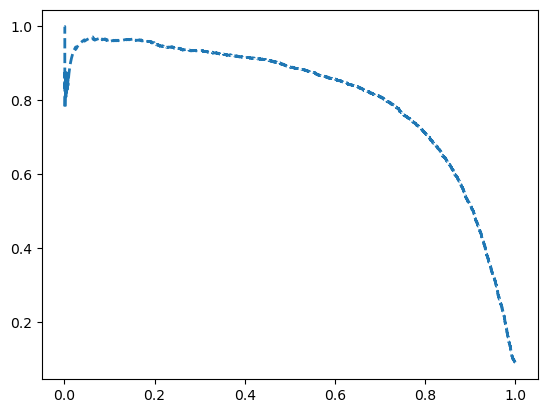

In [31]:
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

**At this threshold value, precision is near 90% and recall is around 50%.**

Suppose you decide to aim for 90% precision.
 Alternatively,
you can search for the lowest threshold that gives you at least 90%
precision. For this, you can use the NumPy array’s argmax() method. This
returns the first index of the maximum value, which in this case means the
first True value:

In [32]:
idx_for_90_precision = (precisions >= 0.90).argmax()

In [33]:
idx_for_90_precision

np.int64(57109)

In [34]:
threshold_for_90_precision = thresholds[idx_for_90_precision]

To make predictions (on the training set for now), instead of calling the
classifier’s predict() method, you can run this code:

In [35]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [36]:
y_train_pred_90

array([False, False, False, ...,  True, False, False], shape=(60000,))

In [37]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [38]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)

In [39]:
recall_at_90_precision

0.4799852425751706

Great, you have a 90% precision classifier! As you can see, it is fairly easy
to create a classifier with virtually any precision you want: just set a high
enough threshold, and you’re done. But wait, **not so fast–a high-precision
classifier is not very useful if its recall is too low! For many applications,
48% recall wouldn’t be great at all**

What does this actually mean in plain English?
**"When my model yells 'It's a 5!', it is correct 90% of the time. BUT, out of all the actual 5s hiding in the dataset, my model only managed to find 48% of them."**


If someone says, “Let’s reach 99% precision”, you should ask, “At what recall?”

### The ROC Curve

In [40]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

- fpr: An array of False Positive Rates (The X-axis of the ROC curve).
- tpr: An array of True Positive Rates / Recall (The Y-axis of the ROC curve).
- thresholds: An array of the threshold values used to get those rates. (Crucial note: Scikit-Learn returns these thresholds sorted from highest to lowest).

Then you can plot the FPR against the TPR using Matplotlib.

In [41]:
idx_for_90_threshold = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_90_threshold], fpr[idx_for_90_threshold]

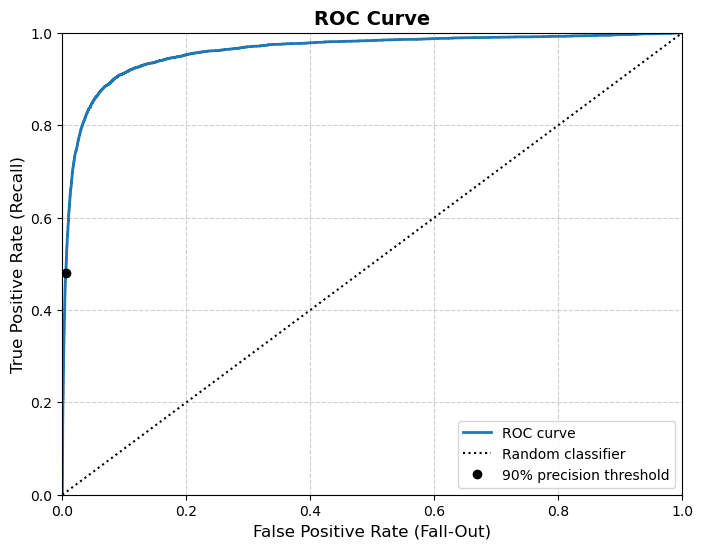

In [42]:
plt.figure(figsize=(8, 6))  # Make the plot bigger

# Plot the ROC curve
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")

# Plot the random classifier line (diagonal)
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier")

# Plot the dot for 90% precision threshold
plt.plot([fpr_90], [tpr_90], "ko", label=f"90% precision threshold")

# Add labels and title
plt.xlabel("False Positive Rate (Fall-Out)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve", fontsize=14, fontweight='bold')

# Add a grid to make it easier to read
plt.grid(True, linestyle='--', alpha=0.6)

# Add the legend (you were missing this!)
plt.legend(loc="lower right", fontsize=10)

# Set axis limits from 0 to 1
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.show()


### 1. Explaining the Plot (The Visuals)

Look at the three main things on your graph:

**A. The Blue Line (Your Model's ROC Curve)**
Notice how the blue line shoots straight up toward the top-left corner and then flattens out? This is a **beautiful** ROC curve. It means your model can achieve a very high Catch Rate (Recall) while keeping the False Alarm Rate (FPR) incredibly low. 

**B. The Dotted Diagonal Line (The "Random Guesser")**
This line represents a model that is completely brain-dead. Imagine a model that just flips a coin to decide if an image is a 5. 
*   If it guesses "5" 50% of the time, it will accidentally catch 50% of the actual 5s (TPR = 0.5). 
*   But it will also falsely accuse 50% of the non-5s (FPR = 0.5). 
*   Because its Catch Rate and its False Alarm Rate are always exactly the same, it draws a perfect **straight diagonal line**. 

**C. The Black Dot (Your 90% Precision Threshold)**
Look at where the black dot is sitting. 
*   **Y-axis (TPR/Recall):** It's at about **0.48**. (It caught 48% of the 5s).
*   **X-axis (FPR):** It's almost at **0.01**. (It only falsely accused 1% of the non-5s).
This perfectly visualizes the trade-off we talked about earlier: to get that 90% precision, your model became so strict that it barely made any false alarms (FPR is near zero), but it also missed more than half the actual 5s (TPR is only 0.48).

---

### 2. Explaining the Text (The Meaning)

The text highlights two massive concepts:

**Concept 1: "The Trade-off"**
> *"the higher the recall (TPR), the more false positives (FPR) the classifier produces."*

Imagine you are moving the black dot along the blue line. If you want to move the dot **UP** (catch more 5s), you *cannot* move it straight up. The curve forces you to slide to the **RIGHT** (make more false alarms). You cannot increase your catch rate without accidentally letting in more garbage. 

**Concept 2: "The Top-Left Corner"**
> *"a good classifier stays as far away from that line as possible (toward the top-left corner)"*

The top-left corner of the graph represents the **Holy Grail of Machine Learning**:
*   **Y-axis = 1.0:** You caught 100% of the actual 5s. (Perfect Recall)
*   **X-axis = 0.0:** You made exactly 0% false alarms. (Perfect Specificity)

No real-world model ever reaches the exact top-left corner, but the goal is to make your blue line "hug" that corner as tightly as possible. The further away your blue line is from the dotted "random guessing" line, the smarter your model is.
s.

One way to compare classifiers is to measure the area under the curve
(AUC). A perfect classifier will have a ROC AUC equal to 1, whereas a
purely random classifier will have a ROC AUC equal to 0.5. Scikit-Learn
provides a function to estimate the ROC AUC:

In [43]:
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

Up to the point where you calculated the **0.96 ROC AUC score**, the book has been taking you through a deep dive into **evaluation**, not necessarily model improvement. You are right that you only trained the `SGDClassifier` once.

Here is a breakdown of what was actually happening, why we did it, and what that final score means.

### 1. What were we actually doing?
You haven't been "improving" the model's intelligence yet; you have been **changing how the model makes its final decision**. 

The `SGDClassifier` computes a numerical score for each image. If that score is above a certain **threshold**, it says "Yes, this is a 5." By default, that threshold is 0. All the "many things" you did (plotting PR curves and ROC curves) were experiments to see what happens if you **move that threshold** up or down.
*   **Lowering the threshold:** The model becomes "relaxed" and says "Yes" more often. You catch more 5s (High Recall), but you also get more false alarms (Low Precision).
*   **Raising the threshold:** The model becomes "picky." You have very few false alarms (High Precision), but you miss a lot of real 5s (Low Recall).

**The meaning of "improvement over time":** In these specific charts, "time" isn't passing. Instead, we are looking at the **trade-off** across all possible threshold settings to see the full range of the model's capabilities.

### 2. What do the scores mean?
*   **Accuracy (95%):** This was a "fake" success. Because only 10% of the data are 5s, a brainless model that always says "No" would be 90% accurate.
*   **Precision (83.7%):** When the model *claims* an image is a 5, it is right about 84% of the time.
*   **Recall (65.1%):** The model only successfully *found* 65% of all the 5s in the deck.
*   **ROC AUC (0.96):** This measures the "Area Under the Curve." It tells you how good the model is at **ranking** images (putting 5s at a higher score than non-5s) regardless of where you set the threshold. 

### 3. Why did we measure all this?
We measure these because **accuracy is a lie on skewed datasets**. You need to know:
1.  **Is the model actually useful?** (A 0.96 AUC sounds great, but we found the PR curve showed it's actually struggling with the rare "5" class).
2.  **Where should we set the "pickiness"?** If this were a kids' video filter, you'd want 99% precision (no bad videos allowed). If it were a shoplifter alarm, you'd want 99% recall (catch every thief, even if there are false alarms).

### 4. The Conclusion
The final result of **0.96** is a "trap" for beginners. While 0.96 looks like an "A+" grade, the book explains that this is **mostly because the positive class (the 5s) is rare**. When you look at the **Precision/Recall (PR) curve** instead, you see that the model's performance drops off significantly when you try to catch most of the 5s.

**The "Final Verdict" of this section:** 
The `SGDClassifier` is an okay "baseline," but it’s not amazing. This evaluation phase taught you that you can't trust a single number like accuracy. Now that you know how to **measure** properly, you are finally ready to do what you were asking about: **actually improve the system** by trying a better model, like the `RandomForestClassifier`, which you'll see immediately outperforms the SGD model.

In [44]:
forest_clf = RandomForestClassifier(random_state=42)

In [45]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [46]:
y_probas_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]], shape=(60000, 2))


It stores a massive 2D grid (a matrix) with **two columns** for every single image:
*   **Column 0:** The probability that the image is **NOT a 5** (Negative class).
*   **Column 1:** The probability that the image **IS a 5** (Positive class).

*(Note: The two columns will always add up to exactly 1.0, or 100%).*




In [47]:
y_scores_forest = y_probas_forest[:, 1]

'''
What does [:, 1] do?
This is a NumPy trick called "slicing".
The : means "give me all the rows (all 60,000 images)".
The 1 means "but only give me column index 1".
'''
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

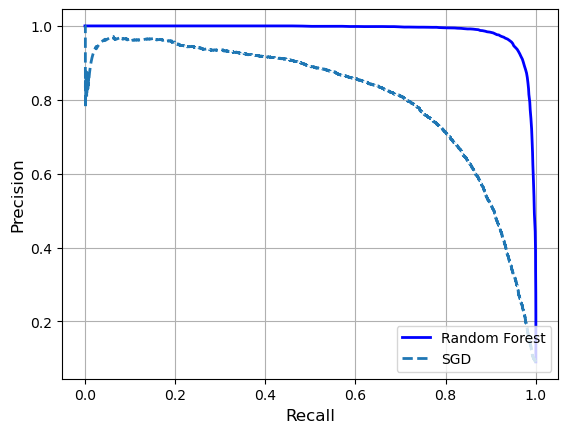

In [48]:


plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")


# Add labels and title
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)

# Add a grid to make it easier to read
plt.grid(True)

plt.legend(loc="lower right", fontsize=10)

plt.show()

In [49]:
y_train_pred_forest = y_probas_forest[:, 1] > 0.5 

In [50]:
f1_score(y_train_5, y_train_pred_forest)

0.9242275142688448

In [51]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [52]:
precision_score(y_train_5, y_train_pred_forest)

0.9905083315756169

In [53]:
recall_score(y_train_5, y_train_pred_forest)

0.8662608374838591

Following the evaluation of the **SGDClassifier**, the next logical step in Chapter 3 is to compare its performance against a more powerful model: the **RandomForestClassifier**. This section demonstrates how to use the evaluation tools you just learned (PR curves and ROC AUC) to objectively choose the better algorithm.

### **1. The Technical Hurdle: Probabilities vs. Scores**
To compare models, they must both provide a numerical "score" for every image. However, these two models work differently:
*   **SGDClassifier:** Uses a `decision_function()` which returns a score (where 0 is the default threshold).
*   **RandomForestClassifier:** Does not have a `decision_function()`. Instead, it provides a **`predict_proba()`** method.

**What we measure:** The `predict_proba()` method returns an array where each row represents an image and each column represents a class (e.g., "5" vs. "not-5"). For our "5-detector," it gives the estimated **probability** that an image is a 5. We use the probability of the positive class as our "score" to feed into the PR and ROC functions.

### **2. Comparing Models via the PR Curve**
The book emphasizes that you should compare the **Precision/Recall (PR) curves** of the two models. 
*   **Why:** A visual comparison is much more revealing than a single number. 
*   **What to look for:** You want the curve that stays closest to the **top-right corner**, which indicates high precision and high recall simultaneously.
*   **The Result:** The Random Forest curve is significantly superior to the SGD curve; it barely drops in precision even as recall increases toward 100%.

### **3. The Final "A+" Scores**
After visualizing the curves, the book calculates the specific performance metrics for the Random Forest to provide a final comparison:

| Metric | SGDClassifier | RandomForestClassifier |
| :--- | :--- | :--- |
| **ROC AUC** | ~0.960 | **~0.998** |
| **$F_1$ Score** | ~0.732 | **~0.924** |
| **Precision** | ~83.7% | **~99.1%** |
| **Recall** | ~65.1% | **~86.6%** |

### **4. Conclusion: Why this matters**
This part of the project demonstrates that while the SGD model’s **0.96 ROC AUC** seemed great initially, the **Random Forest** immediately proved to be much better. 

The comparison reveals a crucial lesson: **you shouldn't just "train and hope."** By using cross-validation and plotting curves, you discovered that:
1.  The Random Forest is much better at **ranking** images (putting 5s at the top and non-5s at the bottom).
2.  The Random Forest can achieve nearly **99% precision** while still finding **86% of all 5s**—a feat the SGD model could not come close to.

Now that you have mastered **binary classification** (detecting just "5"), you are ready to move on to the more complex task of **multiclass classification**, where the model must distinguish between all 10 digits (0 through 9).

# Multiclass Classification

**Multiclass classification** (also called multinomial classification) refers to the task of distinguishing between **more than two classes**. This is a step up from the binary classification covered earlier in Chapter 3, which only distinguished between "5" and "not-5".

### **1. Native vs. Combined Classifiers**
Some machine learning algorithms can handle multiple classes natively, including:
*   **Logistic Regression**.
*   **Random Forest Classifiers**.
*   **Gaussian Naive Bayes**.

However, other algorithms—such as **Stochastic Gradient Descent (SGD)** or **Support Vector Machines (SVM)**—are strictly binary classifiers. To perform multiclass tasks with these, you must use one of two strategies to combine multiple binary models:

### **2. One-versus-the-Rest (OvR) / One-versus-All (OvA)**
This is the most common strategy for most binary classification algorithms.
*   **How it works:** You train one binary classifier for **each class**. For the MNIST digits (0–9), you would train 10 separate detectors (a 0-detector, a 1-detector, etc.).
*   **Making a prediction:** You run an image through all 10 classifiers and select the class that outputs the **highest decision score**.

### **3. One-versus-One (OvO)**
This strategy is preferred for algorithms that **scale poorly** with the size of the training set, such as SVMs.
*   **How it works:** You train a binary classifier for **every possible pair** of digits (e.g., one to distinguish 0s from 1s, another for 0s from 2s).
*   **Complexity:** For $N$ classes, you need $N \times (N – 1) / 2$ classifiers. For MNIST, this means training **45 binary classifiers**.
*   **The Advantage:** Each classifier only needs to be trained on the subset of data containing the two classes it is distinguishing.
*   **Making a prediction:** You run the image through all 45 classifiers and see which class **wins the most "duels"**.

### **4. Scikit-Learn’s Automatic Strategy Selection**
Scikit-Learn detects when you try to use a binary algorithm for a multiclass task and automatically selects a strategy:
*   **SVM (`SVC`):** It automatically uses **OvO**. When you call `decision_function()`, it returns 10 scores—one per class—representing the duels won.
*   **SGD (`SGDClassifier`):** It automatically uses **OvR**. It trains 10 binary classifiers and its `decision_function()` returns the score each classifier assigned to the image.

If you want to force a specific strategy, you can use the `OneVsOneClassifier` or `OneVsRestClassifier` classes and pass your chosen algorithm to their constructor.


Let’s try this with a support vector machine
classifier using the sklearn.svm.SVC class. We’ll only
train on the first 2,000 images, or else it will take a very long time

In [54]:
from sklearn.svm import SVC

In [55]:
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


That was easy! We trained the SVC using the original target classes from 0
to 9 (y_train), instead of the 5-versus-the-rest target classes (y_train_5).
Since there are 10 classes (i.e., more than 2), Scikit-Learn used the OvO
strategy and trained 45 binary classifiers. Now let’s make a prediction on an
image:

In [56]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

since we had put 5 on some digit... so it made correct prediction

In [57]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

The highest score is 9.3, and it’s indeed the one corresponding to class 5

In [58]:
class_id = some_digit_scores.argmax()
class_id
# The argmax operation finds the index or position of the maximum value in a dataset

np.int64(5)

In [59]:
svm_clf.classes_[class_id]

'5'

If you want to force Scikit-Learn to use one-versus-one or one-versus-the-
rest, you can use the OneVsOneClassifier or OneVsRestClassifier
classes. Simply create an instance and pass a classifier to its constructor (it
doesn’t even have to be a binary classifier). For example, this code creates a
multiclass classifier using the OvR strategy, based on an SVC:

In [60]:
from sklearn.multiclass import OneVsRestClassifier


In [61]:
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


In [62]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [63]:
len(ovr_clf.estimators_)

10

**Training an SGDClassifier on a multiclass dataset and using it to make
predictions is just as easy:**

In [64]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])


array(['3'], dtype='<U1')

Oops, that’s incorrect. Prediction errors do happen! This time Scikit-Learn
used the OvR strategy under the hood: since there are 10 classes, it trained
10 binary classifiers. The decision_function() method now returns one
value per class. Let’s look at the scores that the SGD classifier assigned to
each class:

In [65]:
sgd_clf.decision_function([some_digit]).round(2)

array([[-31893.03, -19047.56,  -9530.64,   1823.73, -22320.15,  -1385.8 ,
        -26188.91, -16147.51,  -4604.35, -12050.77]])


### HOW did the model make this decision? (The 10 Scores)

Because Scikit-Learn used the **One-vs-Rest (OvR)** strategy, it actually trained **10 separate binary detectors** under the hood (a 0-detector, a 1-detector, a 2-detector... up to a 9-detector). 

When you pass an image to it, all 10 detectors look at the image and give it a score. The array you see is the score for each digit, **in order from 0 to 9**:

```text
Index 0 (Digit 0): -31,893  (Very confident it's NOT a 0)
Index 1 (Digit 1): -34,420  (Very confident it's NOT a 1)
Index 2 (Digit 2):  -9,531  (Very confident it's NOT a 2)
Index 3 (Digit 3):   1,824  <-- HIGHEST SCORE! (Thinks it MIGHT be a 3)
Index 4 (Digit 4): -22,320  (Very confident it's NOT a 4)
Index 5 (Digit 5):  -1,386  <-- SECOND HIGHEST (Thinks it MIGHT be a 5)
Index 6 (Digit 6): -26,189  (Very confident it's NOT a 6)
...and so on.
```

The model simply looks at this list, finds the **highest number**, and guesses that digit. Because `1,824` is higher than `-1,386`, the "3-detector" won the vote, and the model predicted **3**.

### 3. WHY did it make this mistake?
Look closely at the scores for 3 and 5. 
* The score for 3 is `1,824`.
* The score for 5 is `-1,386`.

Compared to the other digits (which have massive negative scores like `-30,000`), the scores for 3 and 5 are **very close to each other**. 

**This means the model is confused.** 
In handwriting, the number **3** and the number **5** can look incredibly similar (especially if someone writes a 5 with a very curved top, or a 3 with a flat top). The model looked at the image and thought, *"I'm not totally sure, but it looks a little bit more like a 3 than a 5."*



 Since there are roughly the same
number of images in each class, the accuracy metric is fine. As usual, you
can use the cross_val_score() function to evaluate the model

In [66]:
 cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [67]:
 cross_val_score(svm_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.977 , 0.9738, 0.9739])

**Simply scaling the inputs increases
accuracy above 89.1%:**

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()

In [70]:
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

In [71]:

# cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3,scoring="accuracy")

In short, **scaling shrinks the numbers.**

Right now, your images are made of pixels with values from **0 to 255**. That's a pretty big range of numbers for the model's math to handle. 

When you use `StandardScaler`, it takes all those 0-to-255 numbers and shrinks them down so they hover tightly around **0** (for example, between -1.5 and +1.5). 

### Why does this make the model smarter?
Your `SGDClassifier` uses an algorithm called **Gradient Descent** to find the best mathematical line. Imagine Gradient Descent as a blindfolded hiker trying to walk to the very bottom of a valley.

*   **Without Scaling:** The valley is stretched out and weirdly shaped. The hiker zig-zags back and forth, taking a long, inefficient path to the bottom. The model struggles to find the perfect line.
*   **With Scaling:** The valley becomes a perfect, smooth, symmetrical bowl. The hiker walks straight down to the bottom quickly and efficiently. 

By making the math easier and smoother, the model finds a much better mathematical line to separate the digits, which is why your accuracy instantly jumped from **~86% to ~90%** just by shrinking the numbers! 

*(Note: It doesn't change what the image looks like to human eyes, it just changes the raw numbers the model "sees".)*

# Error Analysis

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

/home/sjj/anaconda3/envs/classification_learning/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/sjj/anaconda3/envs/classification_learning/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/sjj/anaconda3/envs/classification_learning/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


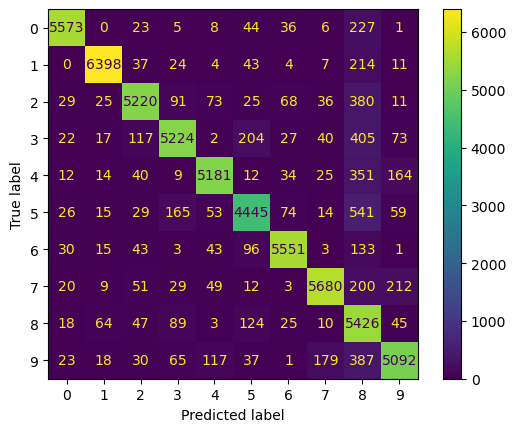

In [73]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()


- **Rows** = True labels (what the images actually are)
- **Columns** = Predicted labels (what the model predicted)
- **Diagonal** (top-left to bottom-right) = Correct predictions

---

## Image 1: Raw Counts (Left Diagram)

This shows the **actual number of images** in each category.

**Example - Reading Row 5 (images that are actually digit 5):**
- Column 5: **4445** → 4,445 images of 5 were correctly classified as 5 ✅
- Column 8: **541** → 541 images of 5 were incorrectly classified as 8 ❌
- Column 3: **165** → 165 images of 5 were incorrectly classified as 3 ❌

**The Problem:** You can't tell if the dark cell for digit 5 means:
- The model made more errors on 5s, OR
- There are fewer 5s in the dataset

That's why we need the second diagram!



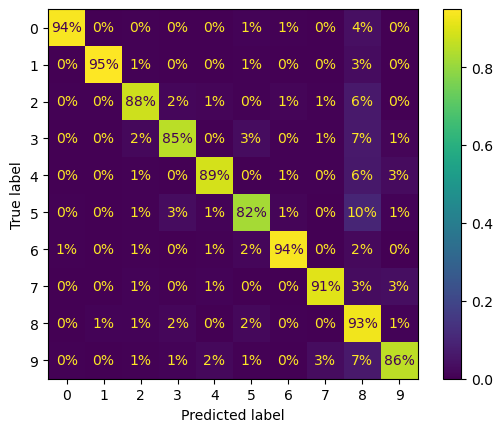

In [74]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

---

## Image 2: Percentages (Right Diagram)

This shows **percentages normalized by row** (each row adds up to 100%).

**Example - Row 5 (actual digit 5):**
- **82%** correctly classified as 5
- **10%** misclassified as 8
- **3%** misclassified as 3
- **1%** misclassified as 6
- etc.

**Now you can see:** Only 82% of 5s were classified correctly - the worst performance of all digits!

---

## Key Insights from Your Model

1. **Best performing digits:** 0 (94%), 1 (95%), 6 (94%), 7 (91%), 8 (93%)

2. **Worst performing digit:** 5 (only 82% correct)

3. **Most common error:** 
   - 5s → 8s (10% of all 5s)
   - This makes sense! Handwritten 5s and 8s can look very similar

4. **Asymmetric errors:**
   - 10% of 5s are misclassified as 8s
   - But only 2% of 8s are misclassified as 5s
   - This tells you the confusion goes mainly one direction

---

Now you know **exactly where to focus your improvement efforts**:
- The model struggles with 5s, especially confusing them with 8s
- You could collect more training data for 5s
- Or engineer features that better distinguish 5s from 8s
- Or try a different model that handles these cases better

**This is much more useful than just knowing "accuracy is 90%"!**

***hide the correct answers and only look at the mistakes.***

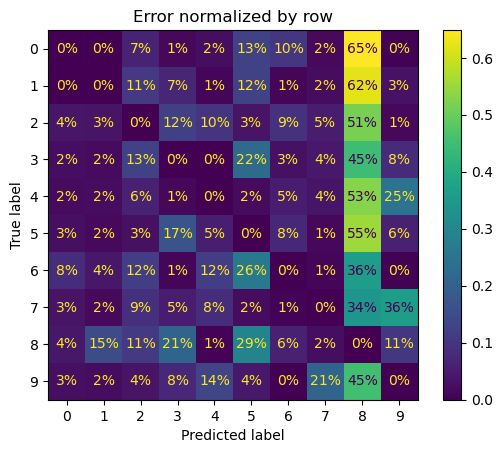

In [75]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize="true", values_format=".0%")
plt.title("Error normalized by row")
plt.show()

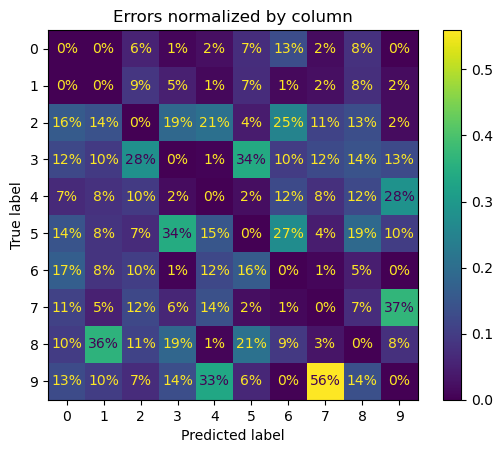

In [76]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize="pred", values_format=".0%")
plt.title("Errors normalized by column")
plt.show()


how to **hide the correct answers and only look at the mistakes.**

---

### 1. The "Mistakes Only" View (The Image You Uploaded)
Look at the diagonal line (0,0 to 9,9). It is completely black (0%). 
This is because the code intentionally set the correct predictions to zero. We are ignoring the good grades and **only looking at the bad ones.**

**How to read a cell in this specific graph:**
Look at the top row (Row 0) and the 8th column (Column 8). It says **65%**.
This means: *"Out of all the times the model looked at a real '0' and made a mistake, **65% of the time it guessed '8'**."*

It is telling you that the number '0' and the number '8' look very similar to your model, and when it gets confused, it almost always thinks a '0' is an '8'.

---

### 2. The "Tricky Math" Warning (Crucial!)
The text gives you a very important warning: **Do not confuse "% of errors" with "% of total".**

The text points out Row 7, Column 9, which says **36%**. 
*   **What it DOES mean:** "Out of all the *mistakes* the model made on the number 7, 36% of them were misclassified as 9s."
*   **What it DOES NOT mean:** It does *not* mean that 36% of all the 7s in the dataset were called 9s. 

**Why?** Because the model is actually really good at guessing 7s! Let's say it gets 97% of the 7s right. That means it only makes mistakes on 3% of them. If 36% of those mistakes are 9s, then 36% of 3% is only about **1% of the total**. 

This is why the text says: *"In reality, only 3% of images of 7s were misclassified as 9s."* (You can see that 3% in the previous, normal confusion matrix).

---

### 3. Normalizing by Column (`normalize="pred"`)
The text ends by mentioning you can flip the math and look at the **Columns** instead of the **Rows**. This completely changes the question you are asking.

*   **Row View (True Label):** *"Out of all the real 7s, what did the model guess?"*
*   **Column View (Predicted Label):** *"Out of all the times the model **guessed** 7, what was the real number?"*

**Why is this useful?**
Imagine your model is overly paranoid and guesses "7" all the time. 
If you look at the **Column** for 7, you might see that 56% of the time it guessed "7", the image was actually a "9". This tells you that your model has a bad habit of confusing 9s for 7s.



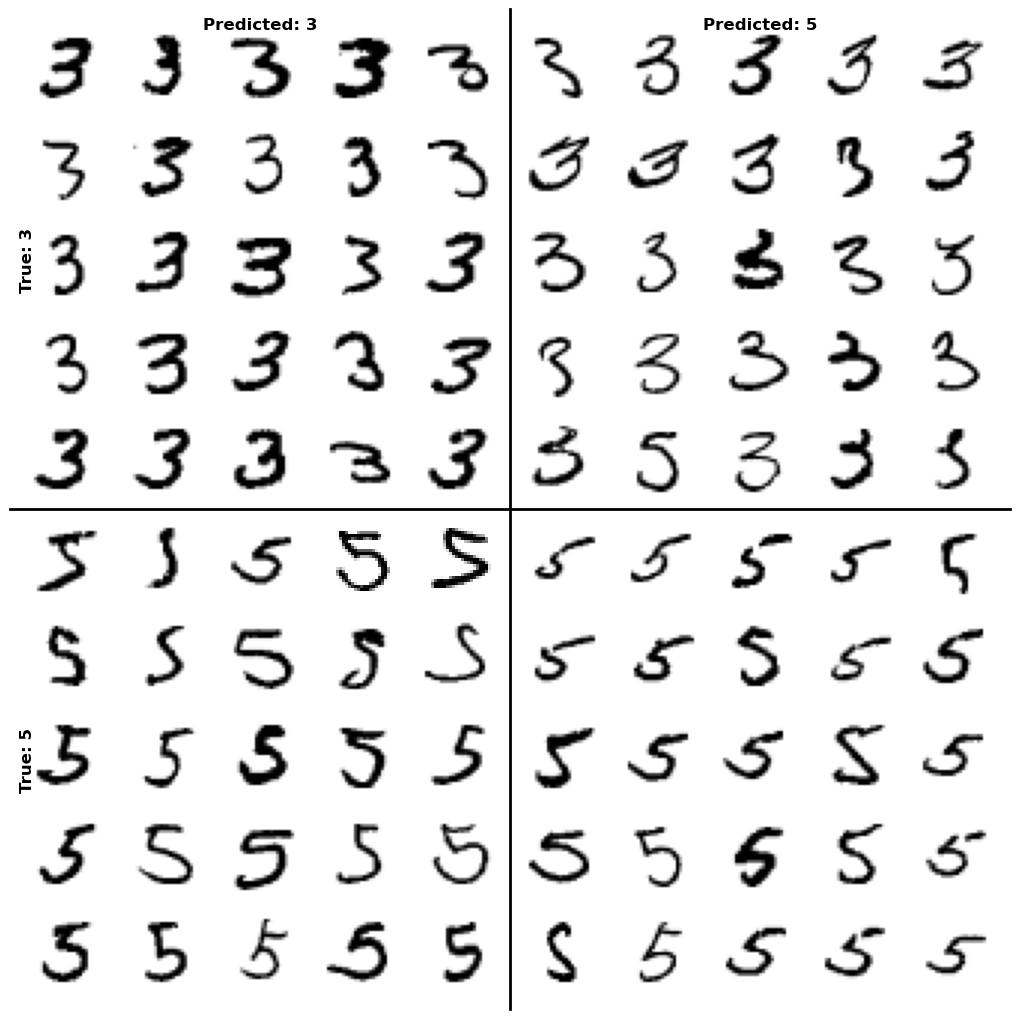

In [77]:
# Extract the specific 3s and 5s
cl_a, cl_b = '3', '5'   # <-- strings, not integers

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

fig, axes = plt.subplots(10, 10, figsize=(10, 10))

# Turn off all axes first
for ax in axes.flatten():
    ax.axis('off')

quadrants = [
    (X_aa, 0, 0),   # True=3, Pred=3  (top-left)
    (X_ab, 0, 5),   # True=3, Pred=5  (top-right)
    (X_ba, 5, 0),   # True=5, Pred=3  (bottom-left)
    (X_bb, 5, 5),   # True=5, Pred=5  (bottom-right)
]

for X, row_start, col_start in quadrants:
    if len(X) == 0:
        continue
    for i in range(5):
        for j in range(5):
            idx = i * 5 + j
            if idx >= len(X):
                break
            ax = axes[row_start + i, col_start + j]
            ax.imshow(X[idx].reshape(28, 28), cmap='binary')

# Add dividing lines between quadrants
fig.add_artist(plt.Line2D([0.5, 0.5], [0, 1], color='black', linewidth=2, transform=fig.transFigure))
fig.add_artist(plt.Line2D([0, 1], [0.5, 0.5], color='black', linewidth=2, transform=fig.transFigure))

fig.text(0.25, 0.98, "Predicted: 3", ha='center', fontsize=12, fontweight='bold')
fig.text(0.75, 0.98, "Predicted: 5", ha='center', fontsize=12, fontweight='bold')
fig.text(0.01, 0.75, "True: 3", va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.01, 0.25, "True: 5", va='center', rotation=90, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

* Top-left (rows 1-5, cols 1-5): True=3, Predicted=3 ✅ → 3s the model got right
* Top-right (rows 1-5, cols 6-10): True=3, Predicted=5 ❌ → 3s the model thought were 5s
* Bottom-left (rows 6-10, cols 1-5): True=5, Predicted=3 ❌ → 5s the model thought were 3s
* Bottom-right (rows 6-10, cols 6-10): True=5, Predicted=5 ✅ → 5s the model got right



# Multilabel Classification

what should it do if it
recognizes several people in the same picture? It should attach one tag per
person it recognizes. Say the classifier has been trained to recognize three
faces: Alice, Bob, and Charlie. Then when the classifier is shown a picture
of Alice and Charlie, it should output [True, False, True] (meaning
“Alice yes, Bob no, Charlie yes”). Such a classification system that outputs
multiple binary tags is called a multilabel classification system

In [78]:
# We won’t go into face recognition just yet, but let’s look at a simpler example, just for illustration purposes

from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') %2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [79]:
knn_clf.predict([some_digit])

array([[False,  True]])


### Part 1: What is Multilabel Classification?
Imagine you are building a face-recognition system for a photo app. 
*   **Multiclass:** "Who is the main person in this photo?" (Answer: Alice).
*   **Multilabel:** "Who is in this photo?" (Answer: Alice AND Charlie).

Instead of outputting a single label, the model outputs a list of `True/False` tags. In the book's example, the tags are `[Is it Alice?, Is it Bob?, Is it Charlie?]`. If Alice and Charlie are in the photo, the model outputs `[True, False, True]`.

### Part 2: Creating the Multilabel Dataset
To demonstrate this without needing complex face-recognition data, the book creates a fake multilabel problem using the MNIST digits:

```python
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
```

**What this code does:**
1.  **`y_train_large`**: Creates a list of True/False. Is the digit 7, 8, or 9?
2.  **`y_train_odd`**: Creates a list of True/False. Is the digit odd (1, 3, 5, 7, 9)?
3.  **`np.c_`**: This is a NumPy trick that **glues two lists together side-by-side**. It turns your two separate lists into a single table (matrix) with two columns. 

Now, every single image in your dataset has **two answers** instead of one.

### Part 3: Training and Predicting
```python
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
knn_clf.predict([some_digit]) # Output: [[False, True]]
```

**What this means:**
You pass the 2-column table into the KNN model. KNN is smart enough to handle multiple columns natively. 
When you pass it the image of a **5**:
*   Column 1 (Is it large?): **False** (5 is not >= 7).
*   Column 2 (Is it odd?): **True** (5 is odd).
The model outputs `[[False, True]]`. It got both right!

---

### Part 4: How to Score a Multilabel Model
When you have two labels, you technically get **two** F1 scores (one for "Large", one for "Odd"). How do you combine them into one final grade? The book gives you two options:

**Option A: `average="macro"`**
*   **How it works:** It just takes the F1 score for "Large", adds it to the F1 score for "Odd", and divides by 2. 
*   **When to use it:** When both labels are equally important to you.

**Option B: `average="weighted"`**
*   **How it works:** It gives more weight to the label that appears more often in the dataset (its "support"). 
*   **When to use it:** When your data is imbalanced. For example, if you have 10,000 pictures of Alice but only 10 pictures of Bob, you probably care more about the model getting Alice right. "Weighted" ensures the final score reflects that priority.

---

### Part 5: The "Classifier Chain" (The Clever Trick)
The text ends with a very cool concept. 

**The Problem:** 
Some models, like the `SVC` (Support Vector Classifier) you used earlier, **do not** support multilabel natively. They only know how to output *one* answer. 

The naive solution is to train two separate SVC models: one for "Large" and one for "Odd". 
*But there's a flaw:* These models don't talk to each other. 
Think about it: If a digit is "Large" (7, 8, 9), it is **twice as likely to be odd** (7, 9) than even (8). If the "Odd" model doesn't know what the "Large" model predicted, it's missing a massive clue!

**The Solution: `ClassifierChain`**
Imagine a relay race. 
1.  **Model 1** looks at the image and guesses if it's "Large".
2.  **Model 2** looks at the image, **BUT it also gets to peek at Model 1's guess** before it decides if it's "Odd". 
3.  If there was a Model 3, it would peek at Model 1 and Model 2's guesses.

By chaining them together, the later models get the benefit of the earlier models' knowledge.

**Why `cv=3` in the code?**
```python
chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
```
If Model 2 just looks at Model 1's guesses on the *training data*, Model 1 might just be memorizing the answers, which would trick Model 2. 
By setting `cv=3`, Scikit-Learn forces Model 1 to make "honest, out-of-sample" predictions (using cross-validation) during training. This ensures Model 2 learns from Model 1's *actual* predictive power, not its memorized training data.



In [80]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [81]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,SVC()
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.",3
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
,"base_estimator base_estimator: estimator, default=""deprecated""Use `estimator` instead... deprecated:: 1.7 `base_estimator` is deprecated and will be removed in 1.9. Use `estimator` instead.",'deprecated'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [82]:
chain_clf.predict([some_digit])

array([[0., 1.]])

# Multioutput Classification

In [83]:
np.random.seed(42) # to make this code example reproducible
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

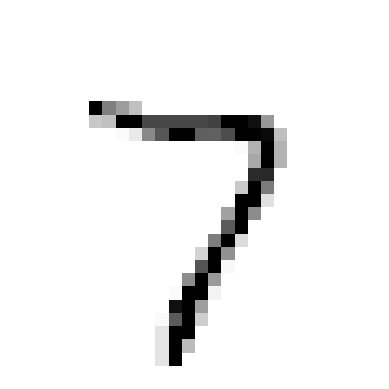

In [84]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

# Multioutput Classification & Image Denoising

This section introduces **multioutput-multiclass classification** using a practical example: **removing noise from images**.

## What is Multioutput-Multiclass Classification?

It's a generalization of multilabel classification where:
- **Multioutput**: Multiple labels per instance (one label per pixel = 784 labels for MNIST)
- **Multiclass**: Each label can have more than two possible values (pixel intensity 0-255)

## The Image Denoising Task

**Goal**: Build a system that cleans noisy digit images

**Input**: Noisy digit image (784 pixels with noise added)  
**Output**: Clean digit image (784 pixels with original intensities)

**Why this is multioutput-multiclass**:
- Each of the 784 pixels is a separate label to predict
- Each pixel can have 256 possible values (0 to 255)

## How the Code Works

### 1. Creating Noisy Training Data

```python
np.random.seed(42)  # For reproducibility
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise  # Noisy images
y_train_mod = X_train           # Clean images (targets)

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_test_mod = X_test
```

**What's happening**:
- `np.random.randint(0, 100, ...)` generates random noise values between 0-99
- This noise is **added** to the original pixel values
- The **noisy images** become the input (what the model sees)
- The **original clean images** become the target (what the model should output)

### 2. Training the Classifier

```python
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
```

The K-Nearest Neighbors classifier learns to map noisy images → clean images.

### 3. Making Predictions

```python
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
```

The model takes a noisy test image and predicts the clean version.

## Visual Example (Figure 3-12)

**Left Image**: Noisy "7" - pixel values are corrupted with random noise  
**Right Image**: Clean "7" - the target the model should produce

The model learns the pattern: "When I see this noisy pattern, the clean version should look like this."

## Important Note: Classification vs. Regression

The book notes that **this example blurs the line between classification and regression**:

- **Classification viewpoint**: Each pixel is a class (0-255 = 256 classes)
- **Regression viewpoint**: Pixel intensity is a continuous value to predict

In practice, predicting pixel intensities is more commonly done with **regression** techniques, but this example demonstrates that multioutput systems can handle both classification and regression tasks.

## Key Takeaways

1. **Multioutput systems** can predict multiple values simultaneously (784 pixels at once)
2. **Each output** can have multiple possible values (0-255 intensity levels)
3. **KNN works well** for this task because similar noisy images will have similar clean versions in the training set
4. **This is a denoising autoencoder** concept - learning to reconstruct clean data from noisy input

This concludes the classification chapter, having covered:
- Binary classification
- Multiclass classification  
- Multilabel classification
- Multioutput classification

You now have the tools to handle various classification scenarios and select appropriate metrics for each!